In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import librosa
import numpy as np
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [2]:
class MFCCProcessor:
    """Handles MFCC extraction and inverse MFCC conversion"""
    
    def __init__(self, sample_rate=16000, n_mfcc=13, n_fft=2048, hop_length=512):
        self.sample_rate = sample_rate
        self.n_mfcc = n_mfcc
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = 40
        
    def extract_mfcc(self, signal):
        """Extract MFCC features from audio signal"""
        if isinstance(signal, torch.Tensor):
            signal = signal.cpu().numpy()
        
        # Handle batch dimension
        if signal.ndim == 2:
            batch_mfcc = []
            for i in range(signal.shape[0]):
                mfcc = librosa.feature.mfcc(
                    y=signal[i], 
                    sr=self.sample_rate, 
                    n_mfcc=self.n_mfcc,
                    n_fft=self.n_fft,
                    hop_length=self.hop_length
                )
                batch_mfcc.append(mfcc)
            return torch.tensor(np.array(batch_mfcc), dtype=torch.float32)
        else:
            mfcc = librosa.feature.mfcc(
                y=signal, 
                sr=self.sample_rate, 
                n_mfcc=self.n_mfcc,
                n_fft=self.n_fft,
                hop_length=self.hop_length
            )
            return torch.tensor(mfcc, dtype=torch.float32)
    
    def inverse_mfcc(self, mfcc_features):
        """Convert MFCC back to approximate time-domain signal"""
        if isinstance(mfcc_features, torch.Tensor):
            mfcc_features = mfcc_features.cpu().numpy()
        
        # Handle batch dimension
        if mfcc_features.ndim == 3:
            batch_signals = []
            for i in range(mfcc_features.shape[0]):
                # Convert MFCC to mel-spectrogram
                mel_spec = librosa.feature.inverse.mfcc_to_mel(
                    mfcc_features[i], 
                    n_mels=self.n_mels
                )
                # Convert mel-spectrogram to audio
                signal = librosa.feature.inverse.mel_to_audio(
                    mel_spec,
                    sr=self.sample_rate,
                    n_fft=self.n_fft,
                    hop_length=self.hop_length
                )
                batch_signals.append(signal)
            return torch.tensor(np.array(batch_signals), dtype=torch.float32)
        else:
            mel_spec = librosa.feature.inverse.mfcc_to_mel(
                mfcc_features, 
                n_mels=self.n_mels
            )
            signal = librosa.feature.inverse.mel_to_audio(
                mel_spec,
                sr=self.sample_rate,
                n_fft=self.n_fft,
                hop_length=self.hop_length
            )
            return torch.tensor(signal, dtype=torch.float32)

In [3]:
class LSTMBranch(nn.Module):
    """LSTM branch for temporal processing"""
    
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.2):
        super(LSTMBranch, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        
        # Output projection
        self.output_proj = nn.Linear(hidden_size * 2, hidden_size)  # *2 for bidirectional
        
    def forward(self, x):
        # x shape: (batch, seq_len) or (batch, seq_len, 1)
        if x.dim() == 2:
            x = x.unsqueeze(-1)  # Add feature dimension
        
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Use the last hidden state
        output = self.output_proj(lstm_out[:, -1, :])  # Take last timestep
        return output

In [4]:
class CNNBranch(nn.Module):
    """2D CNN branch for MFCC processing"""
    
    def __init__(self, input_channels=1, n_mfcc=13):
        super(CNNBranch, self).__init__()
        
        self.conv_layers = nn.Sequential(
            # First conv block
            nn.Conv2d(input_channels, 32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            
            # Second conv block
            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            
            # Third conv block
            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # Global average pooling
        )
        
        self.output_proj = nn.Linear(128, 128)
        
    def forward(self, x):
        # x shape: (batch, n_mfcc, time_frames)
        if x.dim() == 3:
            x = x.unsqueeze(1)  # Add channel dimension: (batch, 1, n_mfcc, time_frames)
        
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.output_proj(x)
        return x

In [5]:
class CrossModalEEGNet(nn.Module):
    """Main cross-modal audio classification network"""
    
    def __init__(self, num_classes=10, sample_rate=16000, n_mfcc=13):
        super(CrossModalEEGNet, self).__init__()
        
        self.mfcc_processor = MFCCProcessor(sample_rate=sample_rate, n_mfcc=n_mfcc)
        
        # Main branches
        self.lstm_branch = LSTMBranch(input_size=1, hidden_size=128)
        self.cnn_branch = CNNBranch(input_channels=1, n_mfcc=n_mfcc)
        
        # Cross-modal branches
        self.cross_lstm = LSTMBranch(input_size=1, hidden_size=128)  # For inverse MFCC signals
        self.cross_cnn = CNNBranch(input_channels=1, n_mfcc=n_mfcc)  # For LSTM-generated MFCC
        
        # Sigmoid gates for cross-modal features
        self.sigmoid_gate1 = nn.Sequential(
            nn.Linear(128, 128),
            nn.Sigmoid()
        )
        self.sigmoid_gate2 = nn.Sequential(
            nn.Linear(128, 128),
            nn.Sigmoid()
        )
        
        # Additional LSTM layers for cross-modal processing
        self.cross_lstm_extra1 = nn.LSTM(128, 64, batch_first=True)
        self.cross_lstm_extra2 = nn.LSTM(128, 64, batch_first=True)
        
        # Flatten layers
        self.flatten1 = nn.Flatten()
        self.flatten2 = nn.Flatten()
        
        # Final classifier (ANN)
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4, 256),  # Concatenated features
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, signal):
        batch_size = signal.size(0)
        
        # ============ Main Branches ============
        # LSTM branch: Process raw signal
        lstm_features = self.lstm_branch(signal)
        
        # CNN branch: Process MFCC features
        mfcc_features = []
        for i in range(batch_size):
            mfcc = self.mfcc_processor.extract_mfcc(signal[i])
            mfcc_features.append(mfcc)
        
        # Pad MFCC features to same length
        mfcc_batch = pad_sequence(mfcc_features, batch_first=True)
        cnn_features = self.cnn_branch(mfcc_batch)
        
        # ============ Cross-Modal Processing ============
        # Path 1: CNN MFCC → Inverse MFCC → Signal → Cross LSTM
        inverse_signals = []
        for i in range(batch_size):
            inv_signal = self.mfcc_processor.inverse_mfcc(cnn_features[i]) #correction hoiche 
            inverse_signals.append(inv_signal)
        
        # Pad inverse signals
        inverse_batch = pad_sequence(inverse_signals, batch_first=True)
        cross_lstm_features = self.cross_lstm(inverse_batch)
        
        # Apply sigmoid gate
        gated_cross_lstm = self.sigmoid_gate1(cross_lstm_features)
        
        # Additional LSTM processing
        gated_cross_lstm_expanded = gated_cross_lstm.unsqueeze(1).expand(-1, 10, -1)  # Expand for LSTM
        # cross_lstm_out1, _ = self.cross_lstm_extra1(gated_cross_lstm_expanded)
        cross_lstm_flat1 = gated_cross_lstm_expanded[:, -1, :]  # Take last timestep
        
        # Path 2: LSTM Signal → MFCC → Cross CNN
        lstm_mfcc_features = []
        for i in range(batch_size):
            # Generate MFCC from LSTM output (using original signal as proxy)
            mfcc = self.mfcc_processor.extract_mfcc(lstm_features[i])  #correction hoiche 
            lstm_mfcc_features.append(mfcc)
        
        lstm_mfcc_batch = pad_sequence(lstm_mfcc_features, batch_first=True)
        cross_cnn_features = self.cross_cnn(lstm_mfcc_batch)
        
        # Apply sigmoid gate
        gated_cross_cnn = self.sigmoid_gate2(cross_cnn_features)
        
        # Additional LSTM processing
        gated_cross_cnn_expanded = gated_cross_cnn.unsqueeze(1).expand(-1, 10, -1)
        # cross_lstm_out2, _ = self.cross_lstm_extra2(gated_cross_cnn_expanded)
        cross_lstm_flat2 = gated_cross_cnn_expanded[:, -1, :]
        
        # ============ Feature Multiplication (Cross-interaction) ============
        # Multiply cross-modal features
        cross_interaction1 = lstm_features * cross_lstm_flat1
        cross_interaction2 = cnn_features * cross_lstm_flat2
        
        # ============ Concatenation and Classification ============
        # Concatenate all features
        fused_features = torch.cat([
            # lstm_features,
            # cnn_features, 
            cross_interaction1,
            cross_interaction2
        ], dim=1)
        
        # Final classification
        output = self.classifier(fused_features)
        
        return output

In [6]:
# Dataset handling for CSV data
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader


class EEGFeatureDataset(Dataset):
    """Dataset class for CSV EEG features"""
    
    def __init__(self, features, labels, transform=None):
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)
        self.transform = transform
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        feature = self.features[idx]
        label = self.labels[idx]
        
        if self.transform:
            feature = self.transform(feature)
            
        return feature, label

In [7]:
def load_csv_dataset(csv_path, test_size=0.2, random_state=42):
    """Load and preprocess CSV dataset"""
    # Load data
    df = pd.read_csv(csv_path)
    y = df["NasaTLX Label"]
    df.drop(columns=["condition", "NasaTLX class", "subject_id", "Condition Label", "NasaTLX Label"], inplace=True)

    if df.isnull().any().any():
        raise ValueError("DataFrame contains missing values.")
        
    # # Separate features and labels
    # X = df.iloc[:, :-1].values  # All columns except last
    # y = df.iloc[:, -1].values   # Last column (labels)

    X= df
    y = y
    
    # Encode labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded, test_size=test_size, random_state=random_state, stratify=y_encoded
    )
    
    # Create datasets
    train_dataset = EEGFeatureDataset(X_train, y_train)
    test_dataset = EEGFeatureDataset(X_test, y_test)
    
    return train_dataset, test_dataset, label_encoder, scaler

In [8]:
# Modified model for feature-based input
class CrossModalFeatureNet(nn.Module):
    """Cross-modal network adapted for pre-extracted features"""
    
    def __init__(self, input_dim=1516, num_classes=3):
        super(CrossModalFeatureNet, self).__init__()
        
        self.input_dim = input_dim
        self.feature_dim = 32
        
        
        # Temporal branch (simulating LSTM processing)
        self.temporal_branch = nn.Sequential(
            nn.Linear(self.input_dim , 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, self.feature_dim)
        )
        
        # Spectral branch (simulating CNN processing)
        self.spectral_branch = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, self.feature_dim)
        )
        
        # Cross-modal processing
        self.cross_temporal = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.Sigmoid(),  # Gate
            nn.Linear(128, self.feature_dim)
        )
        
        self.cross_spectral = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.Sigmoid(),  # Gate
            nn.Linear(128, self.feature_dim)
        )
        
        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim * 4, 128),  # Concatenated features
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # Split input features
        
        # Main branches
        temp_out = self.temporal_branch(x)
        spec_out = self.spectral_branch(x)
        
        # Cross-modal branches
        cross_temp_out = self.cross_temporal(x)
        cross_spec_out = self.cross_spectral(x)
        
        # Feature interactions (multiplication)
        interaction1 = temp_out * cross_temp_out
        interaction2 = spec_out * cross_spec_out
        
        # Concatenate all features
        fused_features = torch.cat([
            temp_out,
            spec_out,
            interaction1, 
            interaction2
        ], dim=1)
        
        # Classification
        output = self.classifier(fused_features)
        return output

In [9]:
# Example usage and training setup
def create_model_for_csv(input_dim=1516, num_classes=3):
    """Create the cross-modal model for CSV feature data"""
    model = CrossModalFeatureNet(
        input_dim=input_dim,
        num_classes=num_classes
    )
    return model

In [10]:
# Visualization and evaluation functions
def plot_training_curves(train_losses, train_accuracies, val_accuracies, save_path=None):
    """Plot training and validation curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss curve
    ax1.plot(train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Accuracy curves
    epochs = range(1, len(train_accuracies) + 1)
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
    ax2.set_title('Training & Validation Accuracy Over Epochs', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [11]:
def evaluate_model(model, test_loader, label_encoder, device):
    """Comprehensive model evaluation"""
    model.eval()
    all_predictions = []
    all_targets = []
    all_probabilities = []
    
    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_targets), np.array(all_probabilities)

In [12]:
def plot_confusion_matrix(y_true, y_pred, label_encoder, save_path=None):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    class_names = label_encoder.classes_
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    
    plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return cm

In [13]:
def print_classification_report(y_true, y_pred, label_encoder):
    """Print detailed classification report"""
    class_names = label_encoder.classes_
    
    print("=" * 60)
    print("CLASSIFICATION REPORT")
    print("=" * 60)
    
    # Overall accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print()
    
    # Detailed classification report
    report = classification_report(y_true, y_pred, target_names=class_names, 
                                 digits=4, output_dict=True)
    
    # Print per-class metrics
    print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<12}")
    print("-" * 60)
    
    for class_name in class_names:
        metrics = report[class_name]
        print(f"{class_name:<12} {metrics['precision']:<12.4f} {metrics['recall']:<12.4f} "
              f"{metrics['f1-score']:<12.4f} {int(metrics['support']):<12}")
    
    print("-" * 60)
    
    # Macro and weighted averages
    macro_avg = report['macro avg']
    weighted_avg = report['weighted avg']
    
    print(f"{'Macro Avg':<12} {macro_avg['precision']:<12.4f} {macro_avg['recall']:<12.4f} "
          f"{macro_avg['f1-score']:<12.4f} {int(macro_avg['support']):<12}")
    
    print(f"{'Weighted Avg':<12} {weighted_avg['precision']:<12.4f} {weighted_avg['recall']:<12.4f} "
          f"{weighted_avg['f1-score']:<12.4f} {int(weighted_avg['support']):<12}")
    
    print("=" * 60)
    
    return report

In [14]:
def plot_class_distribution(y_true, y_pred, label_encoder, save_path=None):
    """Plot class distribution comparison"""
    class_names = label_encoder.classes_
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # True distribution
    true_counts = np.bincount(y_true)
    ax1.bar(class_names, true_counts, color='skyblue', alpha=0.7, edgecolor='black')
    ax1.set_title('True Class Distribution', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Add count labels on bars
    for i, count in enumerate(true_counts):
        ax1.text(i, count + 0.5, str(count), ha='center', va='bottom', fontweight='bold')
    
    # Predicted distribution
    pred_counts = np.bincount(y_pred)
    ax2.bar(class_names, pred_counts, color='lightcoral', alpha=0.7, edgecolor='black')
    ax2.set_title('Predicted Class Distribution', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # Add count labels on bars
    for i, count in enumerate(pred_counts):
        ax2.text(i, count + 0.5, str(count), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [15]:
def analyze_misclassifications(y_true, y_pred, y_prob, label_encoder, top_n=10):
    """Analyze misclassified samples"""
    class_names = label_encoder.classes_
    
    # Find misclassified samples
    misclassified_idx = np.where(y_true != y_pred)[0]
    
    if len(misclassified_idx) == 0:
        print("No misclassifications found!")
        return
    
    print(f"Found {len(misclassified_idx)} misclassified samples")
    print("\nTop misclassified samples (lowest confidence):")
    print("-" * 80)
    
    # Calculate confidence for misclassified samples
    misclassified_confidence = []
    for idx in misclassified_idx:
        pred_class = y_pred[idx]
        confidence = y_prob[idx][pred_class]
        misclassified_confidence.append((idx, confidence))
    
    # Sort by confidence (lowest first)
    misclassified_confidence.sort(key=lambda x: x[1])
    
    print(f"{'Index':<8} {'True':<12} {'Predicted':<12} {'Confidence':<12}")
    print("-" * 50)
    
    for i, (idx, confidence) in enumerate(misclassified_confidence[:top_n]):
        true_class = class_names[y_true[idx]]
        pred_class = class_names[y_pred[idx]]
        print(f"{idx:<8} {true_class:<12} {pred_class:<12} {confidence:<12.4f}")
    
    print("-" * 80)

In [16]:
# Complete training pipeline
def train_model(csv_path, epochs=100, batch_size=32, learning_rate=0.001):
    """Complete training pipeline for CSV dataset"""
    
    # Load dataset
    print("Loading dataset...")
    train_dataset, test_dataset, label_encoder, scaler = load_csv_dataset(csv_path)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Create model
    num_classes = len(label_encoder.classes_)
    input_dim = train_dataset.features.shape[1]
    
    model = create_model_for_csv(input_dim=input_dim, num_classes=num_classes)
    
    # Setup training
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    print(f"Model created successfully!")
    print(f"Device: {device}")
    print(f"Classes: {label_encoder.classes_}")
    print(f"Input dimension: {input_dim}")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Training loop
    best_accuracy = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for batch_idx, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
        train_loss = total_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for data, targets in test_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
        
        val_acc = 100. * val_correct / val_total
        val_accuracies.append(val_acc)
        
        # Update learning rate
        scheduler.step()
        
        # Save best model
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
        
        print(f'Epoch {epoch+1}/{epochs}:')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'  Val Acc: {val_acc:.2f}%')
        print(f'  Best Val Acc: {best_accuracy:.2f}%')
        print('-' * 50)
    
    return model, label_encoder, scaler, train_losses, train_accuracies, val_accuracies, test_loader

In [17]:
def comprehensive_evaluation(model, test_loader, label_encoder, device, 
                           train_losses, train_accuracies, val_accuracies):
    """Perform comprehensive model evaluation with all visualizations"""
    
    print("\n" + "="*60)
    print("COMPREHENSIVE MODEL EVALUATION")
    print("="*60)
    
    # 1. Plot training curves
    print("\n1. Plotting Training Curves...")
    plot_training_curves(train_losses, train_accuracies, val_accuracies, 
                        save_path='training_curves.png')
    
    # 2. Evaluate model and get predictions
    print("\n2. Evaluating Model Performance...")
    y_pred, y_true, y_prob = evaluate_model(model, test_loader, label_encoder, device)
    
    # 3. Classification Report
    print("\n3. Classification Report:")
    classification_report_dict = print_classification_report(y_true, y_pred, label_encoder)
    
    # 4. Confusion Matrix
    print("\n4. Plotting Confusion Matrix...")
    cm = plot_confusion_matrix(y_true, y_pred, label_encoder, 
                              save_path='confusion_matrix.png')
    
    # 5. Class Distribution
    print("\n5. Plotting Class Distributions...")
    plot_class_distribution(y_true, y_pred, label_encoder, 
                           save_path='class_distribution.png')
    
    # 6. Misclassification Analysis
    print("\n6. Analyzing Misclassifications...")
    analyze_misclassifications(y_true, y_pred, y_prob, label_encoder)
    
    # 7. Summary Statistics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    
    final_train_acc = train_accuracies[-1]
    final_val_acc = val_accuracies[-1]
    best_val_acc = max(val_accuracies)
    
    print(f"Final Training Accuracy: {final_train_acc:.2f}%")
    print(f"Final Validation Accuracy: {final_val_acc:.2f}%")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    print(f"Total Test Samples: {len(y_true)}")
    print(f"Correctly Classified: {np.sum(y_true == y_pred)}")
    print(f"Misclassified: {np.sum(y_true != y_pred)}")
    
    # Per-class accuracy
    print(f"\nPer-Class Accuracy:")
    for i, class_name in enumerate(label_encoder.classes_):
        class_mask = y_true == i
        class_acc = np.sum((y_true == y_pred)[class_mask]) / np.sum(class_mask) * 100
        print(f"  {class_name}: {class_acc:.2f}%")
    
    print("="*60)
    print("Evaluation completed! Check saved plots: training_curves.png, confusion_matrix.png, class_distribution.png")
    
    return {
        'predictions': y_pred,
        'true_labels': y_true,
        'probabilities': y_prob,
        'confusion_matrix': cm,
        'classification_report': classification_report_dict,
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }

--------------Updated MFCC Model on SWELL dataset--------------
Starting training...
Loading dataset...
Model created successfully!
Device: cuda
Classes: [0 1 2]
Input dimension: 64
Total parameters: 239,619
Epoch 1/15:
  Train Loss: 0.3544, Train Acc: 85.60%
  Val Acc: 98.86%
  Best Val Acc: 98.86%
--------------------------------------------------
Epoch 2/15:
  Train Loss: 0.0625, Train Acc: 97.98%
  Val Acc: 99.75%
  Best Val Acc: 99.75%
--------------------------------------------------
Epoch 3/15:
  Train Loss: 0.0272, Train Acc: 99.21%
  Val Acc: 99.96%
  Best Val Acc: 99.96%
--------------------------------------------------
Epoch 4/15:
  Train Loss: 0.0157, Train Acc: 99.54%
  Val Acc: 99.98%
  Best Val Acc: 99.98%
--------------------------------------------------
Epoch 5/15:
  Train Loss: 0.0116, Train Acc: 99.68%
  Val Acc: 100.00%
  Best Val Acc: 100.00%
--------------------------------------------------
Epoch 6/15:
  Train Loss: 0.0051, Train Acc: 99.87%
  Val Acc: 99.98%


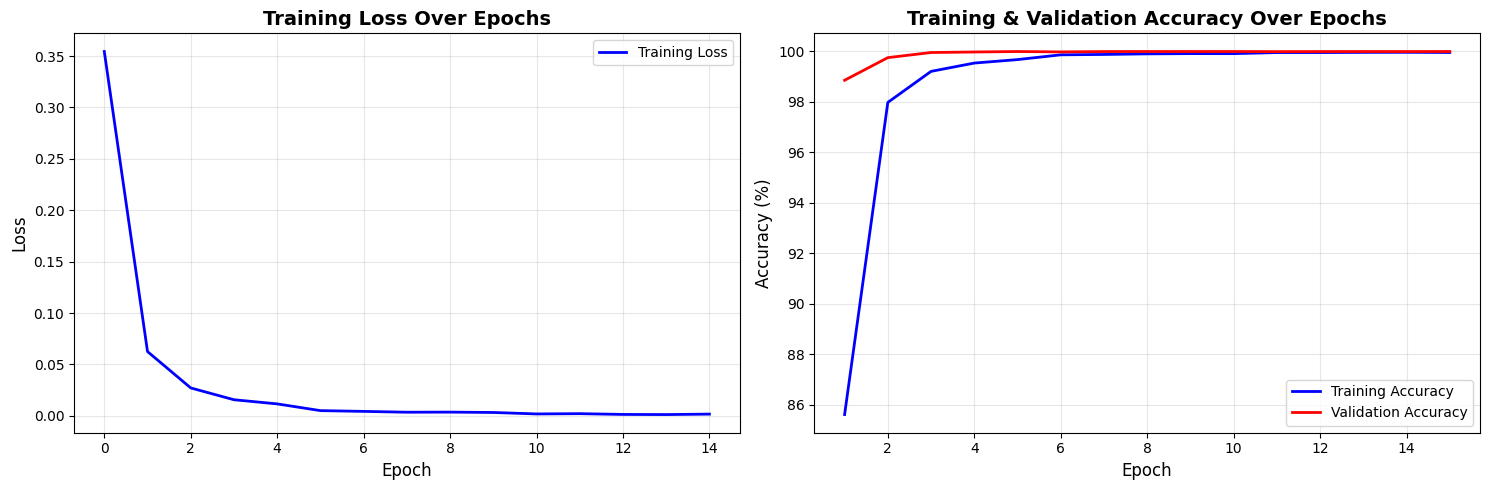


2. Evaluating Model Performance...

3. Classification Report:
CLASSIFICATION REPORT
Overall Accuracy: 1.0000 (100.00%)

Class        Precision    Recall       F1-Score     Support     
------------------------------------------------------------
0            1.0000       1.0000       1.0000       26041       
1            1.0000       1.0000       1.0000       26057       
2            1.0000       1.0000       1.0000       26230       
------------------------------------------------------------
Macro Avg    1.0000       1.0000       1.0000       78328       
Weighted Avg 1.0000       1.0000       1.0000       78328       

4. Plotting Confusion Matrix...


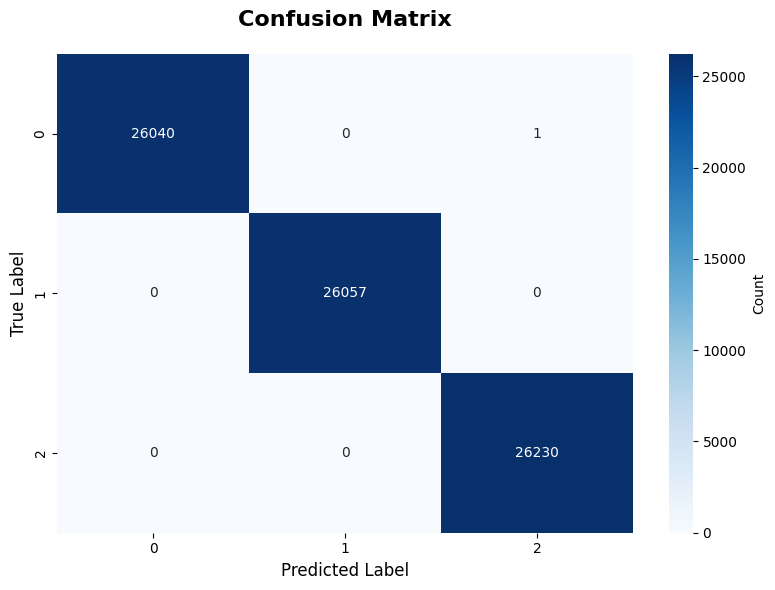


5. Plotting Class Distributions...


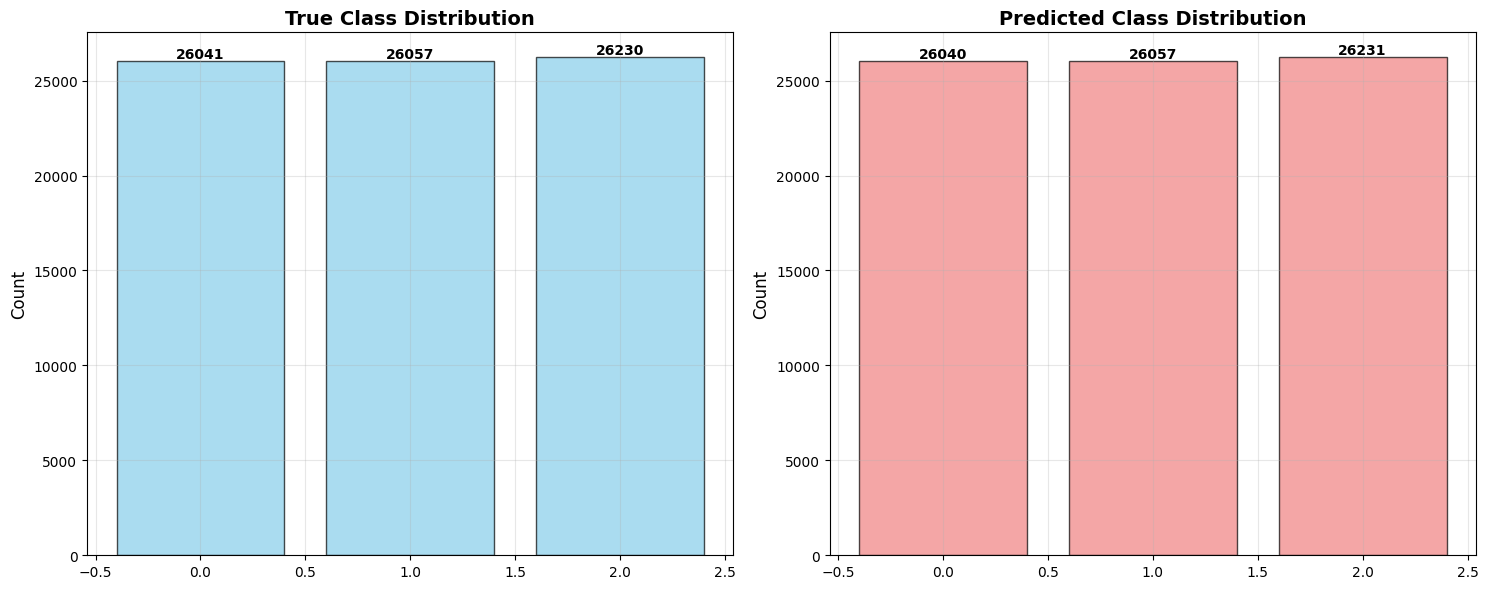


6. Analyzing Misclassifications...
Found 1 misclassified samples

Top misclassified samples (lowest confidence):
--------------------------------------------------------------------------------
Index    True         Predicted    Confidence  
--------------------------------------------------
31794    0            2            0.9877      
--------------------------------------------------------------------------------

SUMMARY STATISTICS
Final Training Accuracy: 99.96%
Final Validation Accuracy: 100.00%
Best Validation Accuracy: 100.00%
Total Test Samples: 78328
Correctly Classified: 78327
Misclassified: 1

Per-Class Accuracy:
  0: 100.00%
  1: 100.00%
  2: 100.00%
Evaluation completed! Check saved plots: training_curves.png, confusion_matrix.png, class_distribution.png

TRAINING AND EVALUATION COMPLETED!
Generated files:
- best_model.pth (saved model)
- training_curves.png (loss and accuracy curves)
- confusion_matrix.png (confusion matrix)
- class_distribution.png (class distributio

In [18]:
# Example usage
if __name__ == "__main__":
    # Example for CSV dataset
    csv_path = "/kaggle/input/stress/dataset/2. final/datasets/hrv/swell/combined/classification/combined-swell-classification-hrv-dataset.csv"  # Replace with your CSV file path
    
    # Train model
    print ("--------------Updated MFCC Model on SWELL dataset--------------")
    print("Starting training...")
    model, label_encoder, scaler, train_losses, train_accuracies, val_accuracies, test_loader = train_model(
        csv_path=csv_path,
        epochs=15,
        batch_size=32,
        learning_rate=0.0001
    )
    
    # Comprehensive evaluation
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    evaluation_results = comprehensive_evaluation(
        model, test_loader, label_encoder, device,
        train_losses, train_accuracies, val_accuracies
    )
    
    # Example prediction on new data
    def predict_sentiment(model, scaler, label_encoder, features):

        """Predict sentiment for new features"""
        model.eval()
        device = next(model.parameters()).device
        
        # Preprocess features
        features_scaled = scaler.transform([features])
        features_tensor = torch.FloatTensor(features_scaled).to(device)
        
        with torch.no_grad():
            outputs = model(features_tensor)
            probabilities = F.softmax(outputs, dim=1)
            predicted_class = outputs.argmax(1).item()
            predicted_label = label_encoder.inverse_transform([predicted_class])[0]
        
        return predicted_label, probabilities.cpu().numpy()[0]
    
    print("\n" + "="*60)
    print("TRAINING AND EVALUATION COMPLETED!")
    print("="*60)
    print("Generated files:")
    print("- best_model.pth (saved model)")
    print("- training_curves.png (loss and accuracy curves)")
    print("- confusion_matrix.png (confusion matrix)")
    print("- class_distribution.png (class distributions)")
    print("\nUse predict_sentiment() function for new predictions.")
    print("="*60)